In [1]:
!pip install shap #Install Libraries

In [2]:
import pandas as pd #Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, roc_curve, auc

import shap

In [5]:
from google.colab import files
uploaded = files.upload()

Saving bank.zip to bank (1).zip


In [7]:
from google.colab import files #Upload CSV File
uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [8]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head() #Explore Dataset


,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"58;""management"";""married"";""tertiary"";""no"";2143..."
1,"44;""technician"";""single"";""secondary"";""no"";29;""..."
2,"33;""entrepreneur"";""married"";""secondary"";""no"";2..."
3,"47;""blue-collar"";""married"";""unknown"";""no"";1506..."
4,"33;""unknown"";""single"";""unknown"";""no"";1;""no"";""n..."


In [9]:
df.shape

(45211, 1)

In [10]:
df.columns

Index(['age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"'], dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 1 columns):
 #   Column                                                                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                                                                --------------  ----- 
 0   age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"  45211 non-null  object
dtypes: object(1)
memory usage: 353.3+ KB


In [12]:
df.isnull().sum()

,0
"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y""",0


In [17]:
' y' #Target Column

' y'

In [18]:
df.columns = df.columns.str.strip()

In [22]:
import pandas as pd

df = pd.read_csv('bank-full.csv', sep=';')

df.columns = df.columns.str.strip()

print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [24]:
X = df.drop('y', axis=1)
y = df['y']

In [25]:
from sklearn.preprocessing import LabelEncoder #Encode Text into Numbers

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [26]:
from sklearn.model_selection import train_test_split #Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(36168, 16)
(9043, 16)


In [27]:
from sklearn.linear_model import LogisticRegression #Train Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [28]:
y_pred_lr = lr.predict(X_test) #Predict

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr) #Evaluate Model
print(cm)

[[7785  167]
 [ 872  219]]


In [30]:
from sklearn.metrics import f1_score #F1 Score

print("F1 Score:", f1_score(y_test, y_pred_lr))

F1 Score: 0.2965470548408937


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.20      0.30      1091

    accuracy                           0.89      9043
   macro avg       0.73      0.59      0.62      9043
weighted avg       0.86      0.89      0.86      9043



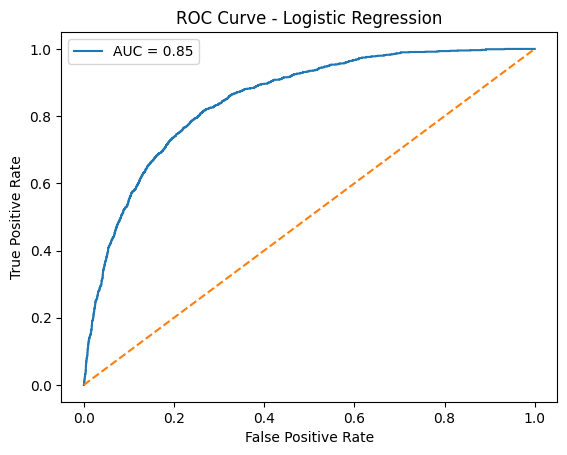

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt #ROC Curve

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier #Random Forest Model

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
y_pred_rf = rf.predict(X_test)

In [35]:
print("F1 Score:", f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

F1 Score: 0.4994438264738598
[[7694  258]
 [ 642  449]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [36]:
!pip install shap

In [38]:
import shap #SHAP Explainability

sample_data = X_test.iloc[:5]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample_data)

In [39]:
shap_vals = shap_values[1]   # positive class (subscription = yes)


===== Prediction 1 =====


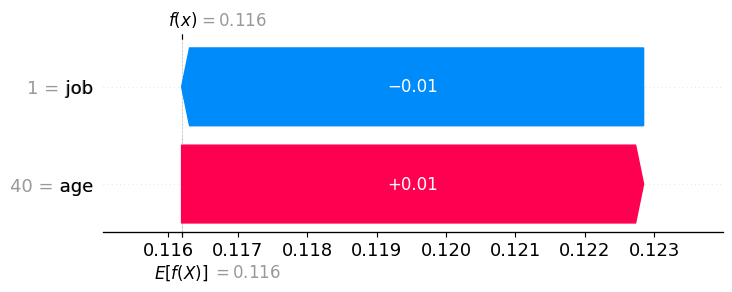


===== Prediction 2 =====


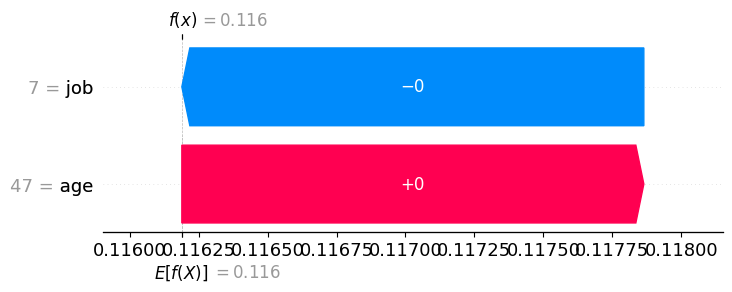


===== Prediction 3 =====


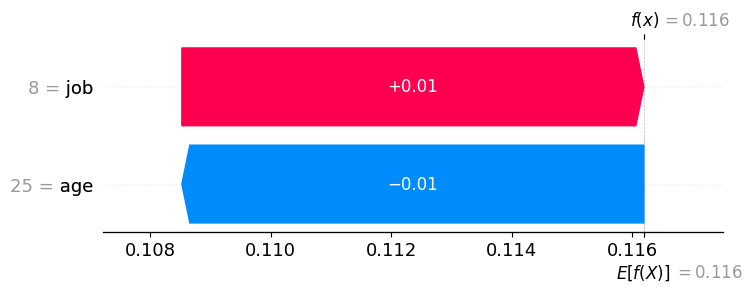


===== Prediction 4 =====


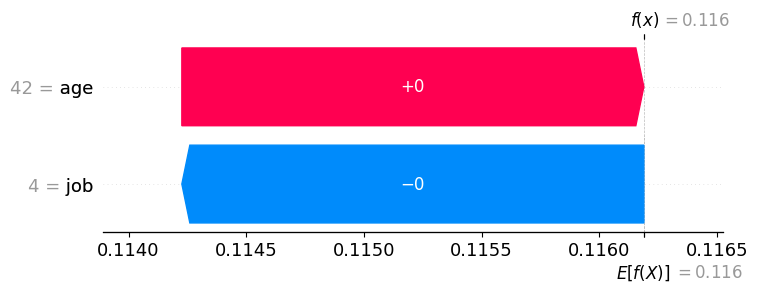


===== Prediction 5 =====


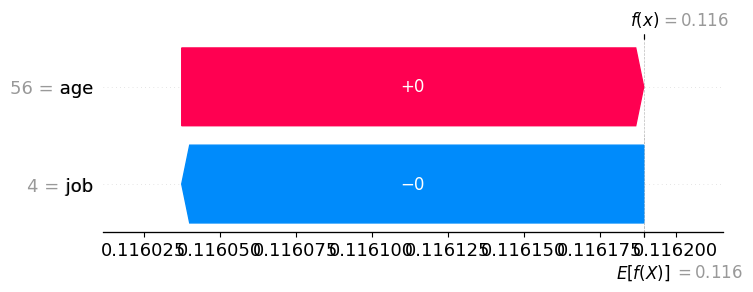

In [40]:
shap.initjs() #Predictions

for i in range(5):
    print(f"\n===== Prediction {i+1} =====")
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_vals[i],
            base_values=explainer.expected_value[1],
            data=sample_data.iloc[i],
            feature_names=sample_data.columns
        )
    )